In [4]:
# read from the csv file the calibration data for a given token

import csv
import numpy as np
import ast

def load_calib_from_csv(csv_file, query_token, cam_channel="CAM_FRONT"):
    with open(csv_file, mode='r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            if row["sample_token"] == query_token and row["cam_channel"] == cam_channel:
                K = np.array(ast.literal_eval(row["K_flat"])).reshape(3, 3)
                R = np.array(ast.literal_eval(row["R_flat"])).reshape(3, 3)
                T = np.array(ast.literal_eval(row["T_flat"])).reshape(3,)
                lidar2img = np.array(ast.literal_eval(row["lidar2img_flat"])).reshape(3, 4)
                img_shape = (int(row["img_height"]), int(row["img_width"]))
                return {
                    "K": K,
                    "R": R,
                    "T": T,
                    "lidar2img": lidar2img,
                    "img_shape": img_shape
                }
    raise KeyError(f"Sample {query_token} with channel {cam_channel} not found in CSV.")


csv_file = "calib_trainval_front.csv"
query_token = "dee909131941447b98da1f253c64c698"  # Replace with your token

calib = load_calib_from_csv(csv_file, query_token)
print("Camera intrinsics K:\n", calib['K'])
print("Camera rotation R:\n", calib['R'])
print("Camera translation T:\n", calib['T'])
print("LiDAR-to-image matrix:\n", calib['lidar2img'])
print("Image shape:", calib['img_shape'])

# for lidar sample 
lidar2img_nusc = calib['lidar2img']
img_shape_nusc = calib['img_shape']

# for camera sample 
k = calib['K']
R = calib['R']
T = calib['T']



Camera intrinsics K:
 [[1.26280936e+03 0.00000000e+00 7.86678463e+02]
 [0.00000000e+00 1.26280936e+03 4.37989095e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Camera rotation R:
 [[-0.0047123   0.01358668  0.99989659]
 [-0.9999733  -0.0056486  -0.00463591]
 [ 0.00558502 -0.99989174  0.01361294]]
Camera translation T:
 [ 1.671 -0.026  1.536]
LiDAR-to-image matrix:
 [[ 1.26036103e+03  7.90443125e+02  1.54990181e+01 -6.36563819e+02]
 [ 7.72955521e+00  4.48268191e+02 -1.25917346e+03 -7.40954528e+02]
 [-3.06328624e-03  9.99962250e-01  8.13112492e-03 -7.75848699e-01]]
Image shape: (900, 1600)


xs torch.Size([133])
ys torch.Size([200])
grid_x torch.Size([133, 200])
grid_y torch.Size([133, 200])


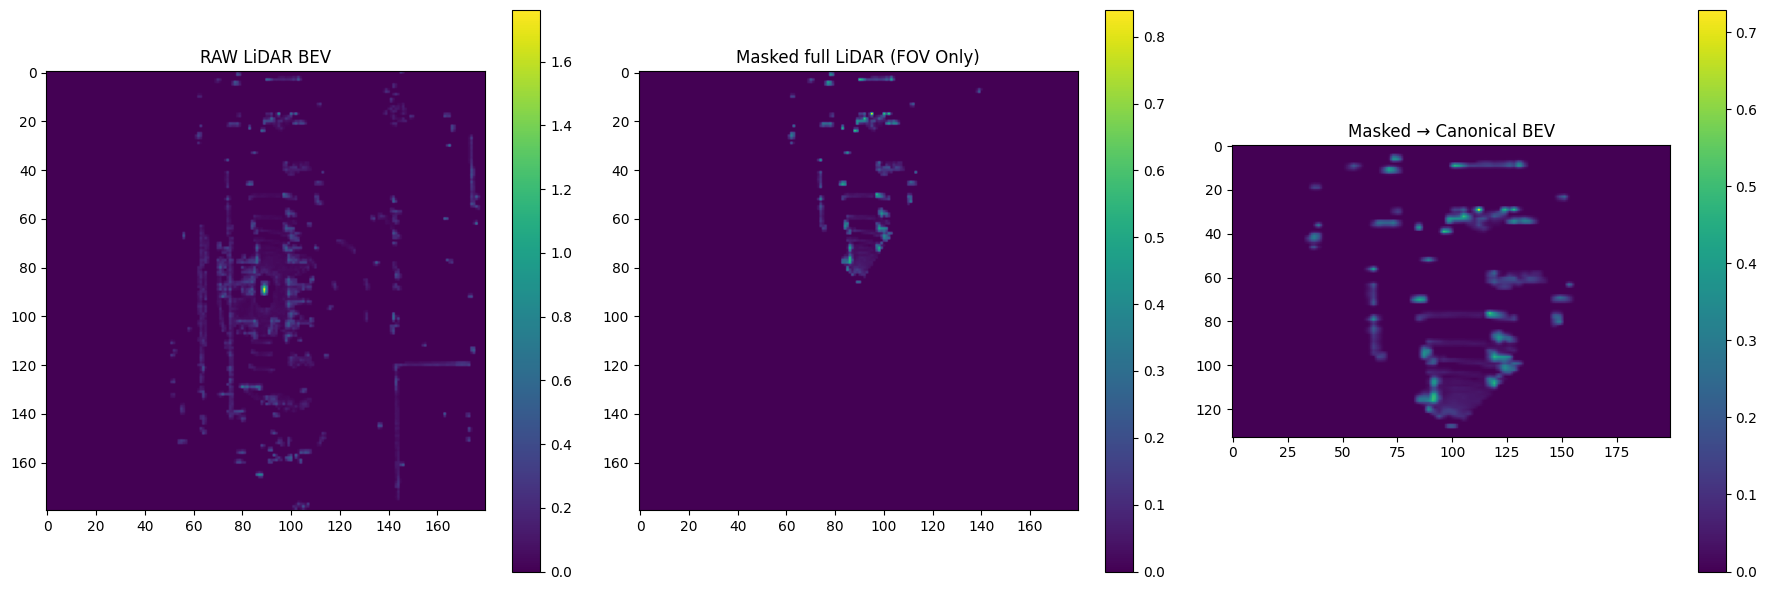

In [ ]:
import sys
sys.path.append("/home/draiman/Desktop/Nima/Lavis_blip2")
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from  lavis.models.crop_lidar_bev import crop_lidar_bev_to_camera_fov

token = "dee909131941447b98da1f253c64c698"

lidar_file_full = f"/data/nusc_lidar/train/{token}.pt"

lidar2img = lidar2img_nusc
img_shape = img_shape_nusc


lidar_raw_full_o = torch.load(lidar_file_full)
lidar_raw_full_nusc = lidar_raw_full_o['spatial'].squeeze(0)
    
masked_full_lidar_nusc = crop_lidar_bev_to_camera_fov(
    lidar_raw_full_nusc,
    lidar2img,
    img_shape,
    # bev_resolution=(1.14, 1.14),
    bev_resolution = (0.57, 0.57),
    pc_range=[-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]
)


class BEVSpec:
    def __init__(self, x_min, x_max, cell_x, y_min, y_max, cell_y):
        self.x_min = x_min
        self.x_max = x_max
        self.cell_x = cell_x
        self.y_min = y_min
        self.y_max = y_max
        self.cell_y = cell_y

    @property
    def H(self):
        return int(np.ceil((self.x_max - self.x_min) / self.cell_x))

    @property
    def W(self):
        return int(np.ceil((self.y_max - self.y_min) / self.cell_y))

bev_spec = BEVSpec(0, 53, 0.4, -25, 25, 0.25)


# Lidar masked: [C, H_raw, W_raw] → add batch
lidar_masked_full_batch = masked_full_lidar_nusc.unsqueeze(0)

x_min_l, y_min_l, _, x_max_l, y_max_l, _ = [-51.2, -51.2, -5, 51.2, 51.2, 3]

xs = bev_spec.x_min + (torch.arange(bev_spec.H) + 0.5) * bev_spec.cell_x
ys = bev_spec.y_min + (torch.arange(bev_spec.W) + 0.5) * bev_spec.cell_y
Xg, Yg = torch.meshgrid(xs, ys, indexing='ij')

grid_x = 2 * (Yg - y_min_l) / (y_max_l - y_min_l) - 1
grid_y = 2 * (Xg - x_min_l) / (x_max_l - x_min_l) - 1
grid = torch.stack([grid_x, grid_y], dim=-1).unsqueeze(0)

lidar_bev_canonical_nusc = F.grid_sample(
    lidar_masked_full_batch, grid,
    mode='bilinear', padding_mode='zeros', align_corners=True
).squeeze(0)


print("xs", xs.shape)
print("ys", ys.shape)
print("grid_x", grid_x.shape)
print("grid_y", grid_y.shape)

masked_full_lidar_mean = masked_full_lidar_nusc.mean(0).numpy()

lidar_raw_full_nusc = torch.rot90(lidar_raw_full_nusc, k=2, dims=[1, 2])
masked_full_lidar_nusc = torch.rot90(masked_full_lidar_nusc, k=2, dims=[1, 2])
lidar_bev_canonical_nusc = torch.rot90(lidar_bev_canonical_nusc, k=2, dims=[1, 2])

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title("RAW LiDAR BEV")
plt.imshow(lidar_raw_full_nusc.mean(0), cmap='viridis')
plt.colorbar()



plt.subplot(1, 3, 2)
plt.title("Masked full LiDAR (FOV Only)")
plt.imshow(masked_full_lidar_nusc.mean(0), cmap='viridis')
plt.colorbar()


plt.subplot(1, 3, 3)
plt.title("Masked → Canonical BEV")
plt.imshow(lidar_bev_canonical_nusc.mean(0), cmap='viridis')
plt.colorbar()

plt.tight_layout()
plt.show()



test camera sample taking info from csv 

torch.Size([1, 256, 116, 200])
H_bev 125
W_bev 200
BEV shape: torch.Size([256, 125, 200])


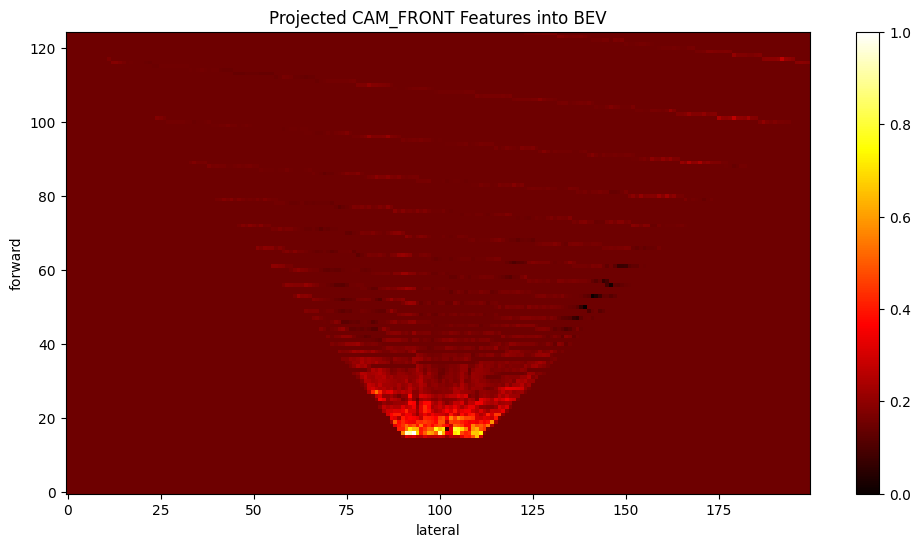

In [6]:
import torch, os
import numpy as np

# -- Settings
camera_dir = "/home/draiman/Desktop/Datasets_nuscenes/train/fpn/CAM_FRONT"
sample_token = "e93e98b63d3b40209056d129dc53ceee"  # Or any sample token
cam_channel = "CAM_FRONT"
fpn_level = 0

K = calib["K"]
R_cam2ego = calib["R"]
T_cam2ego = calib["T"]
img_shape = calib["img_shape"]

# -- Load your FPN P2 features
pt_path = os.path.join(camera_dir, f"{sample_token}_lvl{fpn_level}.pt")
cam = torch.load(pt_path, map_location='cpu')
cam_feat = cam['feat']   # [1, C, Hf, Wf]
if cam_feat.ndim == 3:
    cam_feat = cam_feat.unsqueeze(0)
B, C, Hf, Wf = cam_feat.shape
print(cam_feat.shape)

# -- Compute pixel centers for feature map (using correct stride)
stride = img_shape[0] // Hf   # Assumes integer stride; adjust as needed
i = torch.arange(Hf, dtype=torch.float32) + 0.5
j = torch.arange(Wf, dtype=torch.float32) + 0.5
V, U = torch.meshgrid(i * stride, j * stride, indexing='ij')
U = U.numpy()
V = V.numpy()

# -- Backproject rays → camera → ego
K_inv = np.linalg.inv(K)
uv1 = np.stack([U.reshape(-1), V.reshape(-1), np.ones(Hf*Wf)], axis=0)
rays_cam = K_inv @ uv1
rays_cam[1, :] *= -1  # flip y
rays_ego = R_cam2ego @ rays_cam
C_ego = T_cam2ego.reshape(3)

# -- Intersect rays with ground plane z = 0
cam_z = C_ego[2]
dir_z = rays_ego[2, :]
s = -cam_z / (dir_z + 1e-12)
valid = s > 0
X = C_ego[0] + s * rays_ego[0, :]
Y = C_ego[1] + s * rays_ego[1, :]

# -- Define BEV grid
cell_x = 0.4
cell_y = 0.25
x_min, x_max = 0, 50
y_min, y_max = -25, 25
H_bev = int(np.ceil((x_max - x_min) / cell_x))
W_bev = int(np.ceil((y_max - y_min) / cell_y))
bev = torch.zeros((C, H_bev, W_bev))

# -- Splat features into BEV
ix = ((X - x_min) / cell_x).astype(np.int64)
iy = ((Y - y_min) / cell_y).astype(np.int64)
inside = valid & (ix>=0)&(ix<H_bev)&(iy>=0)&(iy<W_bev)
feat_flat = cam_feat.reshape(C, -1)
for n in np.where(inside)[0]:
    bev[:, ix[n], iy[n]] += feat_flat[:, n]


print("H_bev", H_bev)
print("W_bev", W_bev)
print("BEV shape:", bev.shape)

# -- Visualize BEV heatmap
import matplotlib.pyplot as plt
heat = bev.mean(dim=0).numpy()
heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)
plt.figure(figsize=(12,6))
plt.imshow(heat, cmap='hot', origin='lower', aspect='auto')
plt.colorbar()
plt.xlabel("lateral")
plt.ylabel("forward")
plt.title("Projected CAM_FRONT Features into BEV")
plt.show()
